<a href="https://colab.research.google.com/github/Lu1sV1rus/Estocasticos/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import sympy as sy
import networkx as nx
import matplotlib.pyplot as plt

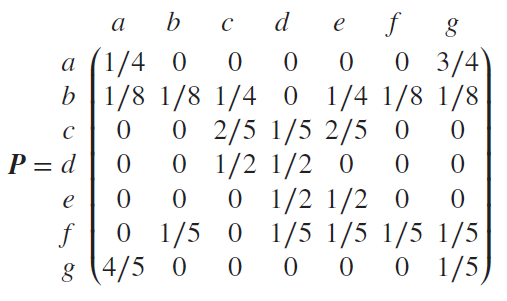

In [9]:
# Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0  ],
    [0,   0,   1/2, 1/2, 0,   0,   0  ],
    [0,   0,   0,   1/2, 1/2, 0,   0  ],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]])

P

array([[0.25 , 0.   , 0.   , 0.   , 0.   , 0.   , 0.75 ],
       [0.125, 0.125, 0.25 , 0.   , 0.25 , 0.125, 0.125],
       [0.   , 0.   , 0.4  , 0.2  , 0.4  , 0.   , 0.   ],
       [0.   , 0.   , 0.5  , 0.5  , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.5  , 0.5  , 0.   , 0.   ],
       [0.   , 0.2  , 0.   , 0.2  , 0.2  , 0.2  , 0.2  ],
       [0.8  , 0.   , 0.   , 0.   , 0.   , 0.   , 0.2  ]])

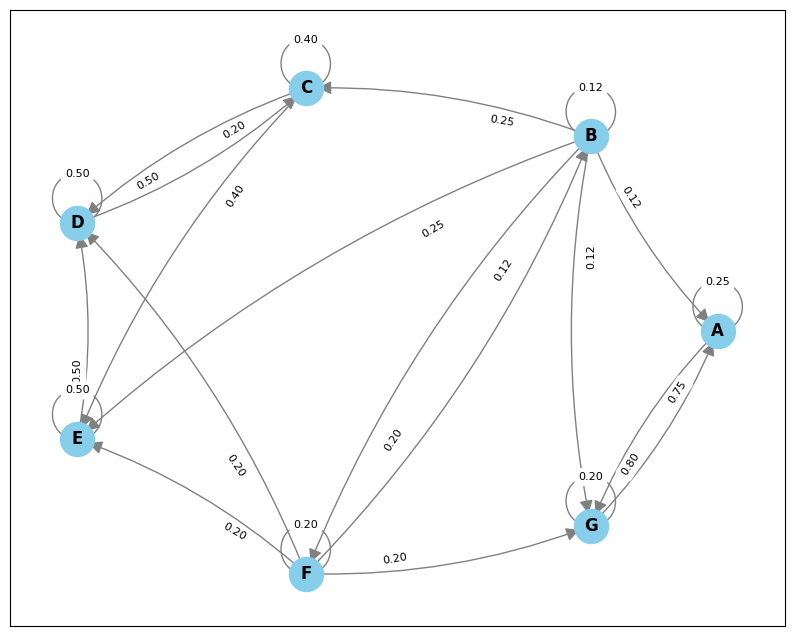

In [10]:
G = nx.from_numpy_array(P, create_using=nx.DiGraph)
G = nx.relabel_nodes(G, dict(enumerate('ABCDEFGHIJK')))

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos, node_size=600, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20,
                       edge_color='gray', connectionstyle='arc3,rad=0.1')

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)

plt.show()

In [11]:
# Determine si la matriz tiene o no distribución límite.

def dislim(P):
  K = nx.from_numpy_array(P, create_using=nx.DiGraph)

  # Irreducibilidad?
  irr = nx.is_strongly_connected(G)

  # Clase
  cla= list(nx.strongly_connected_components(G))

  print(f"¿Es irreducible?: {irr}")
  print(f"\nNumero de clases: {len(cla)}")
  for i, cla in enumerate(cla):
      print(f" Clase {i+1}: {cla}")

  if irr:
      print("\nLa cadena tiene distribucion limite unica .")
  else:
      print("\nEl resultado final depende del estado inicial.")

In [12]:
dislim(P)

¿Es irreducible?: False

Numero de clases: 3
 Clase 1: {'A', 'G'}
 Clase 2: {'E', 'D', 'C'}
 Clase 3: {'F', 'B'}

El resultado final depende del estado inicial.


In [30]:
def analisis_canonico(P):
    P_inf = np.linalg.matrix_power(P, 100)

    G = nx.from_numpy_array(P, create_using=nx.DiGraph)
    recurrentes = [n for n in G.nodes if G.out_degree(n) > 0 and n in set().union(*nx.attracting_components(G))]
    transitorios = [n for n in G.nodes if n not in recurrentes]

    print("Canonica")
    print(f"Recurrentes  : {recurrentes}")
    print(f"Transitorios : {transitorios}")

    print("\n P^n ")
    print(np.round(P_inf[()], 6))

analisis_canonico(P)

Canonica
Recurrentes  : [0, 2, 3, 4, 6]
Transitorios : [1, 5]

 P^n 
[[0.516129 0.       0.       0.       0.       0.       0.483871]
 [0.172043 0.       0.222222 0.266667 0.177778 0.       0.16129 ]
 [0.       0.       0.333333 0.4      0.266667 0.       0.      ]
 [0.       0.       0.333333 0.4      0.266667 0.       0.      ]
 [0.       0.       0.333333 0.4      0.266667 0.       0.      ]
 [0.172043 0.       0.222222 0.266667 0.177778 0.       0.16129 ]
 [0.516129 0.       0.       0.       0.       0.       0.483871]]


In [ ]:
# Escriba un programa que encuentre la descomposición canónica de una matriz dada.